#**Regression Course**





---


In this course, you will learn how to apply ***the supervised learning workflow (explained in Section 4 of the lecture) to regression problems***. We will use **"linear regression" model** throughout the exercises and look at each step of the workflow: ***understanding the data, processing data, model building, and model evaluation***.The goal is to practice the knowledge required for each step depending on the level.

#Level 0（☆☆☆☆）


---
In Level 0, you will learn about linear regression. You will also learn about data characteristics and basic preprocessing methods.

##0.1. Liner Regression

**Linear Regression** is a model which represents the **target variable** (variables you want to predict) as a weighted sum of several **explanatory variables** (variables used to make predictions) plus a bias term.


**【Linear Regression Formula】**


$$f(x) = w_1 x_1 + w_2 x_2 + \dots + w_m x_m + b$$

- $x_{1}, x_{2}, \dots, x_{m}$ : the values of the $m$ explanatory variables.
- $w_1, w_2, \dots, w_m$ : the corresponding weights that indicate how strongly each explanatory variable affects the prediction.
- $b$ : the bias term, representing the predicted value when all explanatory variables are zero.



The model learns to output prediction values close to the actual target values when given explanatory variables.

In the formula above, we wrote the prediction as $f(x)$, which represents a function of the input $x$.
In this notebook, we use $\hat{y}$ to represent the predicted value of the target variable.
The hat symbol (^) is commonly used in statistics and machine learning to indicate an estimated or predicted value.

 If there is one explanatory variable, it is called **simple linear regression**, if there are multiple, it is called **multiple linear regression**.

 In **simple linear regression**, when using a single explanatory variable $x$ to predict target variable $y$, the relationship between the two is represented by the following linear equation:

\begin{equation}
\hat{y} = wx + b
\end{equation}


We refer to $w$ and $b$ as weight and bias, respectively. If the weight and the bias can be determined, you can plug in $x$ to predict $y$. In the scatterplot below, the values were estimated by training to be approximately $w = 0.3$, $b = 0.8$.


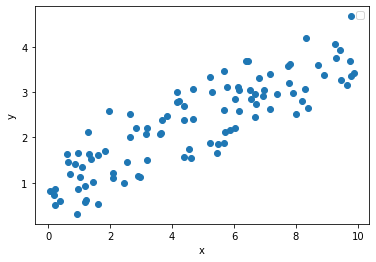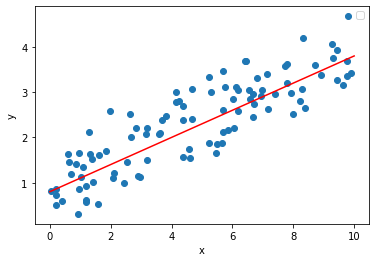

In **multiple linear regression**, when using multiple explanatory variables $x₁, x₂, ..., xₙ$ to predict $y$, the relationship is expressed as the following linear equation:

\begin{eqnarray}
\hat{y} = w_1 \cdot x_1 + w_2 \cdot x_2 + \cdots + w_n \cdot x_n + b
\end{eqnarray}

Here, $w_1, w_2,\cdots,w_n$ are the weights corresponding to each explanatory variable, and $b$ is the bias. Once these are determined, you can substitute values for the explanatory variables $x₁, x₂, ..., xₙ$ to predict $y$.


For example, let’s say we have the following table containing data about car prices.
If the goal is to predict car prices from this information, the price column becomes the target variable, and the width and engine size columns are the explanatory variables.


| ID  | width | engine-size | price |
|-----|--------|--------|---|
| 001 | 65        |   120    |12000 |
| 002 | 70        |   115    |15000|
| 003 | 66        |   130    |13500|
| 004 | 64        |   133    |12100|
| 005 | 67        |   127    |14200|

This time we are doing multiple regression analysis.
When there are two explanatory variables, the model is expressed as:

\begin{equation}
\hat{y} = w_1 \cdot x_1 + w_2 \cdot x_2 + b
\end{equation}


Here, $w₁$ is 940, $w₂$ is 130, and $b$ is -65000.
Substituting these into the equation gives:


\begin{eqnarray}
\hat{y} = 940 \cdot x_1 + 130 \cdot x_2  - 65000
\end{eqnarray}

Thus, the predicted values become the following `pred_price` column:

| ID  | width | engine-size | price | pred_price |
|-----|--------|--------|---|-----|
| 001 | 65        | 120        |12000 | 11700|
| 002 | 70        | 115        |15000| 15750 |
| 003 | 66        | 130        |13500| 13940 |
| 004 | 64        | 133       |12100| 12450 |
| 005 | 67        | 127       |14200| 14490 |

##0.2. Understanding the Data

Let’s learn about important types of data when it comes to understanding data.


Features can be classified into **quantitative** and **qualitative data**.

**Quantitative data** is numerical and expresses information such as width or size on a continuous scale. **Qualitative data**, on the other hand, includes data such as fuel type or whether the car is a hybrid, and represents categories.
These categories are not always binary — for example, the car color may belong to three or more categories.

In linear regression, even qualitative (categorical) data can be converted into numerical values through a process called **dummy variable encoding**, so that they can be used as features.

Dummy variables allow us to transform non-numeric, qualitative data into a form that’s easier for a computer to process.
An example of a dataset with categorical features related to cars is shown in the table below.

| ID  | color | fuel-type |
|-----|------|------|
| 001 | white | diesel |
| 002 | black | gas |
| 003 | white | gas |
| 004 | black | diesel |

For example, when converting categorical data such as car color and fuel type into dummy variables (i.e. 0s and 1s), the table would look like this:

| ID  | color | fuel-type |
|-----|------|------|
| 001 | 0 | 1 |
| 002 | 1 | 0 |
| 003 | 0 | 0 |
| 004 | 1 | 1 |


By converting to dummy variables, categorical data can also be handled as numerical features.

##0.3. Preprocessing Data

To perform data preprocessing and build machine learning models like this, there are **libraries** such as pandas and scikit-learn, which allow for easy implementation. Therefore, as long as you can write minimal code yourself, you can work with data without much difficulty.

External libraries refer to packages (modules) created by organizations outside of Python itself. To use them, you need to **install** and **import** them. In Google Colaboratory, commonly used libraries like pandas and scikit-learn are already installed, so you only need to perform the import step to use them.

In a code cell, you can you can import by writing, `import (library name)`.


>**[Importing a library]**
>
>```Python
>import library_name
>```

Next, let’s import the **pandas** library, which is used to manage tabular data.
Just enter the following code into a code cell to import pandas.
In Python, it is common to give an alias name when importing a library so that it can be used efficiently.
For pandas, the alias `pd` is commonly used.

To use functions in the pandas library, it is necessary to prefix them with the alias `pd`.

Let’s execute the following code in a code cell:

In [ ]:
import pandas as pd

Next, let’s create a table using pandas.
To create a table, you use the `pandas.DataFrame` class.
When creating an instance, you pass either a 2D list or a dictionary where the keys are column names and the values are data.
For strings, be careful not to forget to enclose them in single or double quotes.

>**[Creating a Table in pandas]**
>
>```Python
>Variable_name = pd.DataFrame(2D list)
>```

In [ ]:
df = pd.DataFrame([[57, 120],[52, 130],[55, 115], [51, 140]])
df

,0,1
0,57,120
1,52,130
2,55,115
3,51,140


In a DataFrame, data is managed in rows and columns.
The row numbers on the left side (vertical direction) are called the **indices**, and the names of the **columns** at the top (horizontal direction) are called columns.
By default, the index starts at 0, and there are no column names set unless explicitly defined.

You can assign column names to an existing DataFrame by using the columns attribute and providing a list of new column names like ['column1', 'column2'].
You can also assign column names when creating a DataFrame by specifying a list with the columns argument.

In [ ]:
df.columns = ['column1', 'column2']
df

,column1,column2
0,57,120
1,52,130
2,55,115
3,51,140


To rename columns in a DataFrame, use the `rename()` method.
This method lets you specify the column names you want to change using the columns argument.

For example, if you want to change `column1` to `width` and `column2` to `engine-size`, you would write the code as shown below.


In [ ]:
df = df.rename(columns={'column1': 'width', 'column2': 'engine-size'})
df

,width,engine-size
0,57,120
1,52,130
2,55,115
3,51,140


Using the `to_csv()` method of a DataFrame, you can save the created table as a CSV file as follows:

```
df.to_csv('car_test_data.csv', index=False)
```

By running this, it will save the DataFrame as a file named `data.csv`.
The csv in CSV file stands for comma-separated values, which refers to a format where values are separated by commas **(,)** to separate each column and manage each row with line breaks.

By passing `index=False`, the index numbers will not be saved in the CSV file.

For the data above, the CSV file would look like this:

---



width, engine-size

57,120

52,130

55,115

51,140





In [ ]:
df.to_csv('car_test_data.csv', index = False)

By running the code above, a CSV file will be saved.
Click the file icon on the left side of Google Colaboratory to confirm that the file `car_test_data.csv` is saved.
Right click to download it to your local environment. CSV files can also be opened in spreadsheet software like Excel.
You can also open the CSV file directly in Google Colaboratory. By clicking on the file, you can check its content in the sidebar of Google Colaboratory.

To read the saved file, use pandas' `read_csv()` function to import the file and store it as a variable:

In [ ]:
df2 = pd.read_csv('car_test_data.csv')
df2

,width,engine-size
0,57,120
1,52,130
2,55,115
3,51,140


In section 0.3, you learned the basic operations for handling data using pandas:
*   Importing pandas
*   Handling DataFrames
*   How to save as a CSV file



##0.4. Model Building and Evaluation

To build a machine learning model, you will import the **scikit-learn** machine learning library.
The import method is the same as when using pandas.
scikit-learn offers various types of models, but you only need to import the model you want to use.

When importing scikit-learn, one thing to note is that the library is called ***sklearn*** in the code.
We will use LinearRegression, the class for linear regression models, from the linear_model module of sklearn.

Here is how to import it:

>**[Importing the LinearRegression class from scikit-learn's linear_model module]**
>
>```Python
>from sklearn.linear_model import LinearRegression
>```

By using `from ... import ...`, you can specify and import only the class you need.
You can then use it with the format: `module_name.class_name`.

Now, let’s go ahead and build a simple linear regression model.

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

With just these two lines, we have now created a linear regression model. In the second line, we instantiated the class we imported. This way, you can simply assign the instance to a variable using the class name, and creating a model instance becomes easy.

Now, we just need to train the model with the data to complete the predictive model.
Here, we will use data related to car prices explained by linear regression.
Let's begin by running the code block below.

In [ ]:
import pandas as pd
test_data = pd.DataFrame(
    [
        [65, 120, 12000],
        [70, 115, 15000],
        [66, 130, 13500],
        [64, 133, 12100],
        [67, 127, 14200],
    ],
    columns=["width", "engine-size", "price"],
)
test_data

,width,engine-size,price
0,65,120,12000
1,70,115,15000
2,66,130,13500
3,64,133,12100
4,67,127,14200


Now, let’s separate the explanatory variables and target variable from this table and train the machine learning model.
To extract specific columns from a DataFrame, add [['Column1', 'Column2']] after the variable name to extract the columns you want.
Let’s extract the explanatory variables.

In [ ]:
x = test_data[['width', 'engine-size']]
x

,width,engine-size
0,65,120
1,70,115
2,66,130
3,64,133
4,67,127


You can extract the target variable the same way.
Since it’s just one column, you don’t need to use a list; you can simply enclose the column name in quotes.

In [ ]:
t = test_data['price']
t

,price
0,12000
1,15000
2,13500
3,12100
4,14200


Now, let’s pass the explanatory variables and the target variable to the model and train it.
In scikit-learn's machine learning model training, the `fit()` method is used.

In [ ]:
model.fit(x, t)

LinearRegression()

Training is completed with just this line.

Here, we assume a linear regression formula using the two explanatory variables width and engine-size, as follows:

\begin{eqnarray}
\hat{y} = w_1 \cdot x_1 + w_2 \cdot x_2  + b
\end{eqnarray}

Let’s check the estimated bias and how the estimated weights are derived.
The estimated bias is stored in the attribute `intercept_`, and the weights are stored in the attribute `coef_`.

By putting variables inside a string using curly braces {} and placing f before the string, you can embed the variable values inside the string.

In [ ]:
print(f'Estimated bias: {model.intercept_}')
print(f'Estimated weights: {model.coef_}')

Estimated intercept: -45289.90362964962
Estimated coefficients: [725.63271188  83.74313249]


From the expression above, we can now say:
$w₁$ = 725.63271188, $w₂$ = 83.74313249, and $b$ = -45289.90362964962.
Therefore, we can interpret this as:
“For every 1 unit increase in vehicle width, the predicted price increases by approximately 725.63.”

In linear regression, the method used to calculate the bias and weights is called **least squares**.
This method minimizes the sum of squared differences between the actual target variable (true value) and the predicted value.


**【Linear Regression Formula】**
$$
\hat{y}  = f(x) = w_1 x_1 + w_2 x_2 + \dots + w_m x_m + b
$$




In least squares, the following value is minimized:

$$
\sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2
$$


*n* : the number of data points in the dataset.

$y_i$ : the actual value of the target variable for the $i$-th observation.

$\hat{y}_i$  :the predicted value for the $i$-th observation.


That concludes the supervised learning workflow for regression problem.
Using an external library called scikit-learn, you can construct a machine learning prediction model in just three lines of code:

* Import the machine learning library → from ... import ...
* Create an instance of the model → model = LinearRegression()
* Fit the model to the data → model.fit()


Level 0 content ends here. To wrap up, let’s try the following practical exercises as a review.

##0.5. Practice Problems

In Level 0, you learned about the characteristics of data, preprocessing methods, and linear regression.
Based on the contents of Level 0, please work through the following practice problems.

**Q0-1.** Create a pandas DataFrame using the table below.

|  | column1 | column2 | Price |
|-----|------|------|--|
| 0 | 50 | 128   | 12000 |
| 1 | 65 | 147   | 13400 |

**Q0-2.** Rename the columns: `column1` as `height` and `column2` as `horsepower`.

**Q0-3.** Save the above table as a CSV file with an appropriate file name (e.g., `data.csv`).
Make sure the file has been saved.
Note: Use single quotes when writing string values.

That’s all for Level 0. Great job!